# 动图demo

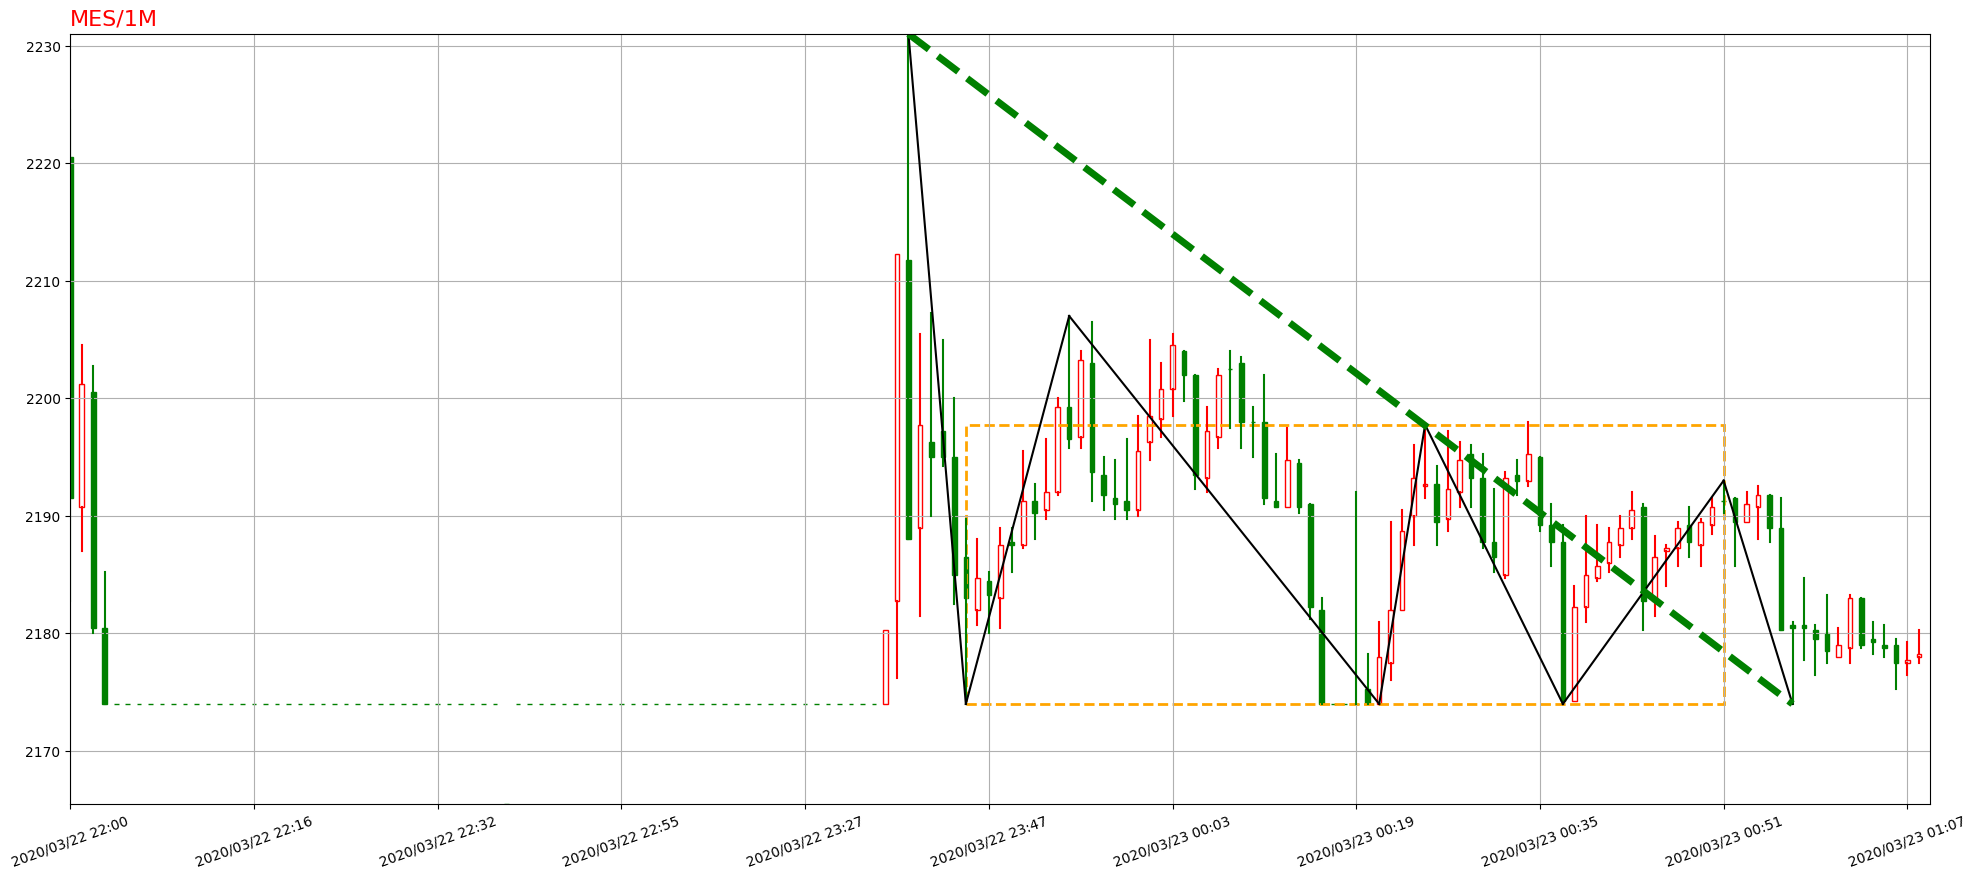

KeyboardInterrupt: 

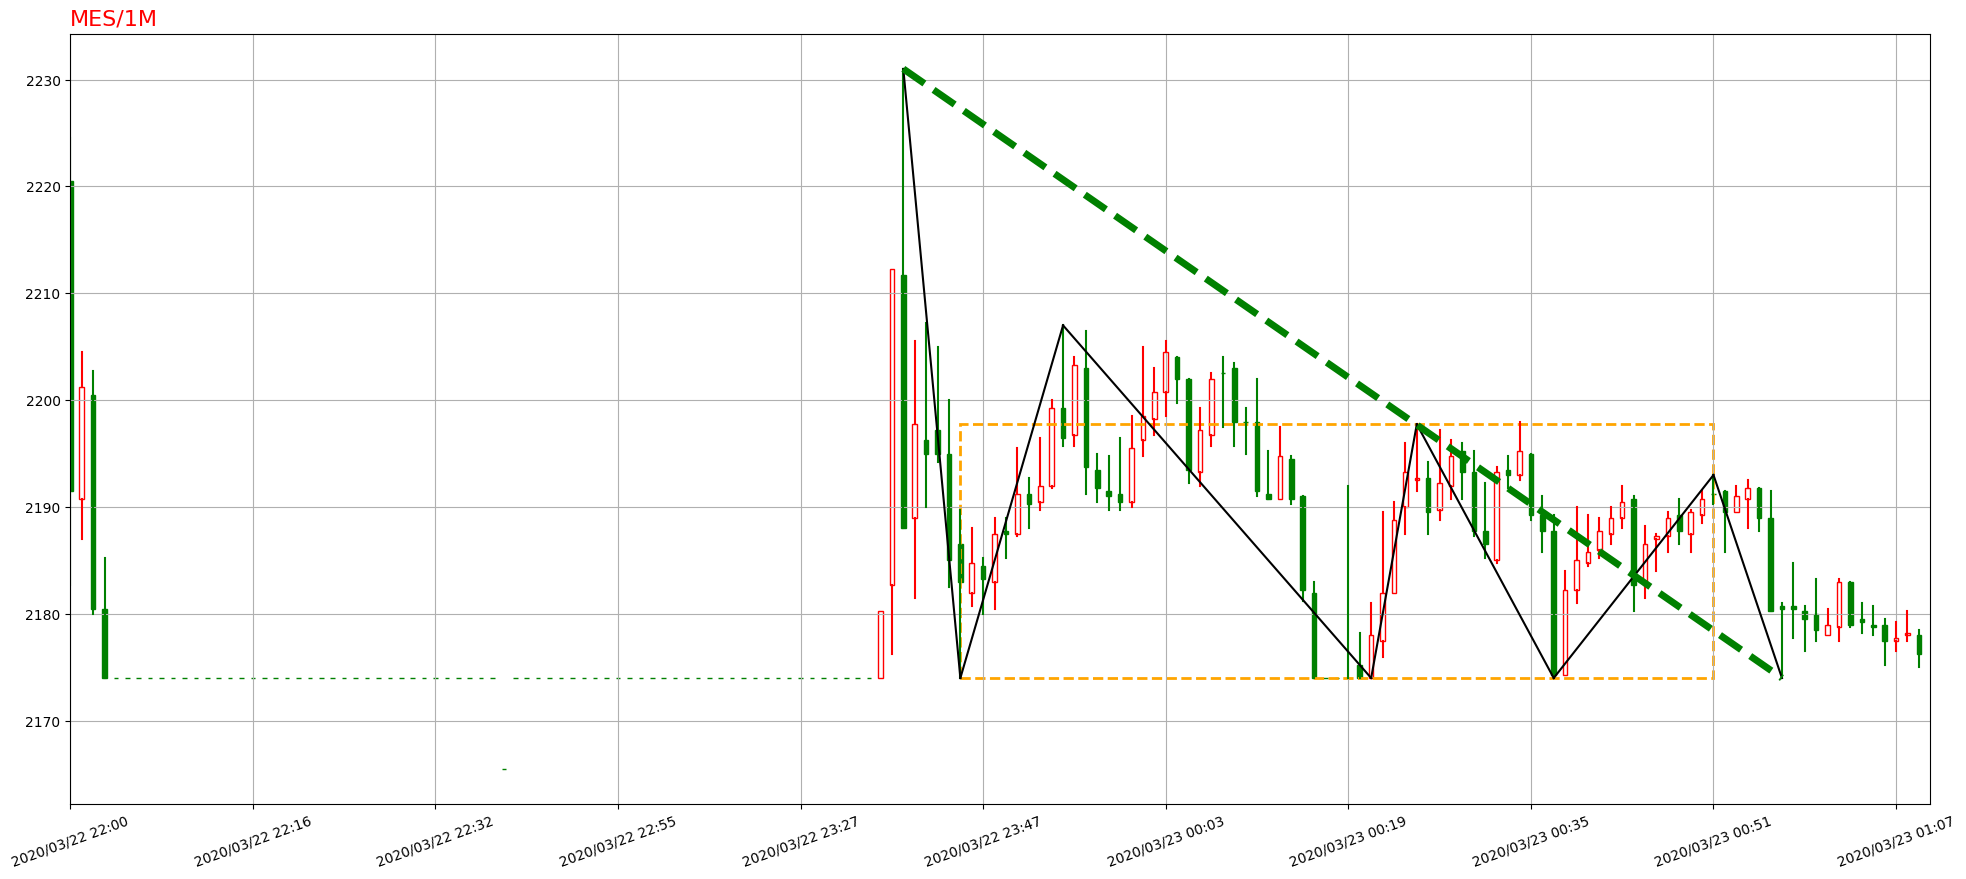

In [ ]:
# import sys
# import os

# # 获取当前脚本(demo.py)所在的目录（即Debug目录）
# current_dir = os.path.dirname(os.path.abspath(__file__))
# # 获取上层目录（即project目录，因为Debug的父目录是project）
# parent_dir = os.path.dirname(current_dir)
# # 将上层目录添加到Python的模块搜索路径中
# sys.path.append(parent_dir)
# print(parent_dir)

import json
from typing import Dict, TypedDict

import xgboost as xgb
from strategy_demo5 import stragety_feature

from BuySellPoint.BS_Point import CBS_Point
from Chan import CChan
from ChanConfig import CChanConfig
from ChanModel.Features import CFeatures
from Common.CEnum import AUTYPE, DATA_SRC, KL_TYPE
from Common.CTime import CTime
from Plot.PlotDriver import CPlotDriver
from Plot.AnimatePlotDriver import CAnimateDriver


class T_SAMPLE_INFO(TypedDict):
    feature: CFeatures
    is_buy: bool
    open_time: CTime


def animate_plot(chan, plot_marker):
    """使用CAnimateDriver创建动态图"""
    plot_config = {
        "plot_kline": True,
        "plot_bi": True,
        "plot_seg": True,
        "plot_zs": True,
        "plot_bsp": True,
        "plot_marker": True,
    }
    plot_para = {
        "figure": {
            "x_range": 1000,
        },
        "marker": {
            "markers": plot_marker
        }
    }
    
    # 使用CAnimateDriver创建动态图
    CAnimateDriver(
        chan,
        plot_config=plot_config,
        plot_para=plot_para,
    )


def predict_bsp(model: xgb.Booster, last_bsp: CBS_Point, meta: Dict[str, int]):
    missing = -9999999
    feature_arr = [missing] * len(meta)
    for feat_name, feat_value in last_bsp.features.items():
        if feat_name in meta:
            feature_arr[meta[feat_name]] = feat_value
    feature_arr = [feature_arr]
    dtest = xgb.DMatrix(feature_arr, missing=missing)
    return model.predict(dtest)


if __name__ == "__main__":
    """
    本demo主要演示如何在实盘中把策略产出的买卖点，对接到demo5中训练好的离线模型上
    """
    code = "MES"
    begin_time = "20200320220000000"
    end_time = "20200403081400000"
    data_src = DATA_SRC.CSV
    lv_list = [KL_TYPE.K_1M]

    config = CChanConfig({
        "trigger_step": True,  # 打开开关！用于动态图
    })

    chan = CChan(
        code=code,
        begin_time=begin_time,
        end_time=end_time,
        data_src=data_src,
        lv_list=lv_list,
        config=config,
        autype=AUTYPE.QFQ,
    )

    model = xgb.Booster()
    model.load_model("model.json")
    meta = json.load(open("feature.meta", "r"))

    treated_bsp_idx = set()
    plot_marker = {}  # 存储绘图标记
    
    for chan_snapshot in chan.step_load():
        # 策略逻辑要对齐demo5
        last_klu = chan_snapshot[0][-1][-1]
        bsp_list = chan_snapshot.get_latest_bsp()
        if not bsp_list:
            continue
        last_bsp = bsp_list[0]

        cur_lv_chan = chan_snapshot[0]
        if last_bsp.klu.idx in treated_bsp_idx or cur_lv_chan[-2].idx != last_bsp.klu.klc.idx:
            continue

        last_bsp.features.add_feat(stragety_feature(last_klu))  # 开仓K线特征
        
        # 买卖点打分
        score = predict_bsp(model, last_bsp, meta)[0]
        
        # 根据分数判断有效性（使用0.5作为阈值）
        is_valid = score > 0.3
        marker_text = f"{'√' if is_valid else '×'}\n{score:.3f}"
        direction = "down" if last_bsp.is_buy else "up"
        
        # 记录到plot_marker中
        plot_marker[last_bsp.klu.time.to_str()] = (marker_text, direction)
        
        print(f"{last_bsp.klu.time} - Score: {score:.4f} - {'BUY' if last_bsp.is_buy else 'SELL'} - {'VALID' if is_valid else 'INVALID'}")
        treated_bsp_idx.add(last_bsp.klu.idx)

    # 创建一个新的CChan实例用于动态绘图
    chan_animate = CChan(
        code=code,
        begin_time=begin_time,
        end_time=end_time,
        data_src=data_src,
        lv_list=lv_list,
        config=config,
        autype=AUTYPE.QFQ,
    )

    # 绘制动态图表
    if plot_marker:
        print(f"\nTotal trading points: {len(plot_marker)}")
        print("Generating animated plot...")
        animate_plot(chan_animate, plot_marker)
    else:
        print("No trading points to plot")